<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Simulate_Cross_HCP_to_TMS_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Simulate_Cross_HCP_to_TMS_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fast Cross-Dataset Validation: HCP Models → TMS-fMRI

**Objective**: Fast, memory-efficient validation by simulating **ONE rest + ONE stim per HCP subject per target** (not per empirical session).

**Key Differences from Per-Session Approach**:
- **Input initialization**: Random uniform or zeros (not empirical rest data)
- **Simulation count**: ~1100 (11 targets × 100 subjects) vs. ~40,000 (per-session)
- **Stimulation timing**: Representative timing extracted from target-level empirical data
- **Output**: Per-subject FC matrices, averaged across HCP subjects for target comparison

**Workflow**:
1. Load HCP trained models and TMS empirical data
2. For each target, extract representative stimulus timing from empirical sessions
3. For each HCP subject:
   - Initialize with random uniform (or zeros)
   - Simulate rest condition (no stimulation)
   - Simulate stim condition (with typical target-level timing)
   - Compute FC matrices
4. Average FC across HCP subjects → target-specific means
5. Compare to empirical means via Pearson correlation

**Advantages**:
- ~40× fewer simulations → ~40× faster
- No empirical data initialization → tests model's intrinsic stimulus response
- More memory efficient → can run on standard GPU

## Step 1: Setup and Configuration

In [1]:
# Setup Google Colab (if needed)
import os, sys, pickle
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    repo_dir = "/content/BrainStim_ANN_fMRI_HCP"
    if not os.path.exists(repo_dir):
        !git clone https://github.com/grabuffo/BrainStim_ANN_fMRI_HCP.git
    else:
        print("✓ Repo already exists")
    sys.path.append(repo_dir)
except ImportError:
    repo_dir = '/Users/cbc/Documents/GitHub/fufo/notebook/ANN_background/BrainStim_ANN_fMRI_HCP-main'
    sys.path.insert(0, repo_dir)

import numpy as np
import pandas as pd
import torch
from scipy.spatial.distance import cdist
from collections import defaultdict
from src.preprocessing_tms_fmri import preprocess_run
from src.NPI import build_model, device

print(f"Working directory: {repo_dir}")
print(f"PyTorch device: {device}")

Mounted at /content/drive
Cloning into 'BrainStim_ANN_fMRI_HCP'...
remote: Enumerating objects: 939, done.
remote: Counting objects: 100% (199/199), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 939 (delta 91), reused 14 (delta 14), pack-reused 740 (from 2)
Receiving objects: 100% (939/939), 109.72 MiB | 24.36 MiB/s, done.
Resolving deltas: 100% (351/351), done.
Working directory: /content/BrainStim_ANN_fMRI_HCP
PyTorch device: cpu


## Step 2: Configuration Parameters

In [4]:
# Data directories
try:
    base_dir = "/content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data"
except:
    base_dir = "/Users/cbc/Documents/GitHub/fufo/notebook/ANN_background/BrainStim_ANN_fMRI_HCP-main/data"

data_dir = base_dir

# HCP data directory
hcp_preproc_dir = os.path.join(base_dir, "preprocessed_subjects")
hcp_weights_dir = os.path.join(hcp_preproc_dir, "trained_models_MLP")

# TMS data directory
tms_data_dir = os.path.join(base_dir, "TMS_fMRI")
tms_preproc_dir = os.path.join(base_dir, "preprocessed_subjects_tms_fmri")
dataset_pkl = os.path.join(tms_data_dir, "dataset_tian50_schaefer400_allruns.pkl")

# Distance matrix for spatial kernel
dist_matrix_path = os.path.join(tms_data_dir, "atlases", "distance_matrix_450x450_Tian50_Schaefer400.npy")

# ROI configuration
cortical_roi_indices = np.arange(50, 450)  # Schaefer 400 (exclude Tian 50 subcortical)
n_rois = len(cortical_roi_indices)  # 400 cortical ROIs

# Simulation parameters
tr_hcp = 0.72  # HCP effective TR for stimulus timing precision
tr_stim = 2.4  # TMS fMRI TR (from empirical data)
ds_factor = tr_stim / tr_hcp  # ~3.33x downsampling
using_steps = 3  # Rolling window size for ANN input
burn_in = 30  # Steps before stimulus application
stim_amp = 10.0  # Stimulation amplitude
noise_sigma = 0.28  # Stochastic noise
rho_mm = 60.0  # Spatial Gaussian spread

# For random initialization
init_method = 'random_uniform'  # or 'zeros'
init_scale = 0.1  # Scale for random uniform initialization

print(f"Configuration:")
print(f"  Cortical ROIs: {n_rois}")
print(f"  TR HCP (sim): {tr_hcp}s, TR TMS (emp): {tr_stim}s")
print(f"  Downsampling factor: {ds_factor:.2f}x")
print(f"  Burn-in: {burn_in} steps")
print(f"  Init method: {init_method} (scale={init_scale})")
print(f"  HCP models dir: {hcp_weights_dir}")
print(f"  TMS data dir: {tms_data_dir}")

Configuration:
  Cortical ROIs: 400
  TR HCP (sim): 0.72s, TR TMS (emp): 2.4s
  Downsampling factor: 3.33x
  Burn-in: 30 steps
  Init method: random_uniform (scale=0.1)
  HCP models dir: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects/trained_models_MLP
  TMS data dir: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/TMS_fMRI


## Step 3: Load Distance Matrix and Spatial Kernel

In [5]:
# Load distance matrix and create spatial Gaussian kernel
try:
    D = np.load(dist_matrix_path)  # Shape: (450, 450)
    print(f"✓ Loaded distance matrix: shape {D.shape}")

    # Create spatial Gaussian kernel W
    W = np.exp(-(D ** 2) / (2.0 * (rho_mm ** 2))).astype(np.float32)
    W /= (W[np.arange(450), np.arange(450)][:, None] + 1e-8)  # Normalize so target = 1
    print(f"  Spatial kernel W shape: {W.shape}, range [{W.min():.4f}, {W.max():.4f}]")
except FileNotFoundError as e:
    print(f"⚠ Distance matrix not found: {e}")
    print(f"  Will use identity kernel (no spatial spread)")
    W = np.eye(450, dtype=np.float32)

✓ Loaded distance matrix: shape (450, 450)
  Spatial kernel W shape: (450, 450), range [0.0176, 1.0000]


## Step 4: Load HCP Models

In [6]:
# Load all trained HCP models
# Models are saved as .pt files (torch.save format) with naming: id_XXXXXX_MLP.pt

# Add safe globals for PyTorch model serialization
from src import NPI
torch.serialization.add_safe_globals([NPI.ANN_MLP, NPI.ANN_CNN, NPI.ANN_RNN, NPI.ANN_VAR])

trained_models = {}

if os.path.exists(hcp_weights_dir):
    model_files = [f for f in sorted(os.listdir(hcp_weights_dir)) if f.endswith('_MLP.pt')]
    print(f"Found {len(model_files)} .pt files in {hcp_weights_dir}")

    for model_file in model_files:
        model_path = os.path.join(hcp_weights_dir, model_file)
        # Extract subject ID from filename (e.g., "id_100206_MLP.pt" → "id_100206")
        sub_id = model_file.replace('_MLP.pt', '')

        try:
            # Load with weights_only=False to allow loading full model objects
            model = torch.load(model_path, map_location=device, weights_only=False)
            if hasattr(model, 'eval'):
                model = model.to(device)
                model.eval()
            trained_models[sub_id] = model
        except Exception as e:
            print(f"    ✗ Failed to load {sub_id}: {str(e)}")

    print(f"✓ Loaded {len(trained_models)} HCP models:")
    for sub_id in sorted(trained_models.keys())[:5]:
        print(f"    {sub_id}")
    if len(trained_models) > 5:
        print(f"    ... and {len(trained_models) - 5} more")
else:
    print(f"⚠ HCP models directory not found: {hcp_weights_dir}")

Found 10 .pt files in /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects/trained_models_MLP
✓ Loaded 10 HCP models:
    id_100206
    id_100307
    id_100408
    id_101006
    id_101107
    ... and 5 more


## Step 6: Helper Functions for Simulation

In [7]:
def compute_fc_matrix(timeseries):
    """
    Compute Fisher-z transformed FC matrix from timeseries.

    Args:
        timeseries: (T, n_rois) array

    Returns:
        fc_z: Fisher-z transformed FC (n_rois, n_rois)
    """
    # Compute Pearson correlation
    fc = np.corrcoef(timeseries.T)

    # Fisher-z transform
    fc_z = 0.5 * np.log((1 + fc) / (1 - fc + 1e-6))
    fc_z = np.nan_to_num(fc_z, nan=0.0, posinf=0.0, neginf=0.0)

    return fc_z

def extract_upper_triangle(fc_matrix, k=1):
    """
    Extract upper triangle (excluding diagonal) of symmetric matrix.
    """
    indices = np.triu_indices(fc_matrix.shape[0], k=k)
    return fc_matrix[indices]

def downsample_timeseries(ts_hires, ds_factor):
    """
    Downsample timeseries by averaging blocks.
    """
    ds_factor = int(np.round(ds_factor))
    T = ts_hires.shape[0]
    T_down = T // ds_factor
    ts_downsampled = ts_hires[:T_down * ds_factor].reshape(T_down, ds_factor, -1).mean(axis=1)
    return ts_downsampled

def get_onset_column(df, preferred_cols=['onset', 'OnsetTime', 'stim_time']):
    """Find stimulus onset column in dataframe."""
    for col in preferred_cols:
        if col in df.columns:
            return col
    return df.columns[0] if len(df.columns) > 0 else None

def map_onsets_to_steps(onsets_seconds, tr_model=tr_stim):
    """Map onset times (in seconds) to simulation steps."""
    return np.round(onsets_seconds / tr_model).astype(int)

print("Helper functions defined.")

Helper functions defined.


## Step 7: Initialize Control Timeseries

In [8]:
def create_random_init(init_method='random_uniform', scale=0.1, n_rois=450, window_size=3):
    """
    Create random initialization for simulation.

    Args:
        init_method: 'random_uniform' or 'zeros'
        scale: Scale factor for random uniform
        n_rois: Number of brain regions
        window_size: Rolling window size\n
    Returns:
        init_window: (window_size, n_rois) array
    """
    if init_method == 'zeros':
        init_window = np.zeros((window_size, n_rois), dtype=np.float32)
    else:  # random_uniform
        init_window = np.random.uniform(-scale, scale, size=(window_size, n_rois)).astype(np.float32)
    return init_window

print("Random initialization function defined.")

Random initialization function defined.


## Step 8: ANN Inference Functions

In [9]:
def predict_next(model, x, target_idx, W, device='cpu'):
    """
    Predict next timestep using ANN model.

    Args:
        model: PyTorch ANN model
        x: Input activity (using_steps, 450)
        target_idx: Target ROI index
        W: Spatial kernel (450, 450)

    Returns:
        next_step: Predicted activity (450,)
    """
    with torch.no_grad():
        # Prepare input
        x_input = torch.tensor(x.flatten(), dtype=torch.float32, device=device).unsqueeze(0)

        # Forward pass
        x_pred = model(x_input).cpu().numpy()[0]

    return x_pred

def simulate_run(model, init_state, n_steps, stim_steps=None, target_idx=0, W=None,
                 burn_in=30, stim_amp=10.0, noise_sigma=0.28, device='cpu'):
    """
    Simulate ANN for n_steps with optional spatial TMS stimulation.

    Args:
        model: PyTorch ANN model
        init_state: Initial activity (using_steps, 450)
        n_steps: Number of simulation steps
        stim_steps: Set/list of step indices where to apply stimulation
        target_idx: Target ROI for stimulation (0-449)
        W: (450, 450) spatial Gaussian kernel for TMS spread
        burn_in: Steps before applying stim
        stim_amp: Stimulation amplitude
        noise_sigma: Noise standard deviation

    Returns:
        ts: Full timeseries (n_steps, 450)
    """
    if stim_steps is None:
        stim_steps = set()
    else:
        stim_steps = set(int(s) for s in stim_steps)

    init_state = np.asarray(init_state, dtype=np.float32)
    assert init_state.shape == (using_steps, 450)

    # Prepare output
    ts = np.zeros((n_steps, 450), dtype=np.float32)
    w = init_state.copy()

    # Burn-in phase: let model settle without stimulation
    for _ in range(burn_in):
        y = predict_next(model, w, target_idx, W, device=device)
        # Add noise
        noise = np.random.normal(0, noise_sigma, size=y.shape).astype(np.float32)
        y = y + noise
        # Update rolling window
        w = np.vstack([w[1:], y[None, :]])

    # Simulate with optional stimulation
    for t in range(n_steps):
        # Apply spatial TMS stimulation if this is a stim step
        if target_idx is not None and t in stim_steps:
            if W is not None:
                # Apply spatial Gaussian spread of stimulation across all ROIs
                w[-1, :] += stim_amp * W[target_idx, :]
            else:
                # Fallback: apply to target region only
                w[-1, target_idx] += stim_amp

        # Get model prediction
        y = predict_next(model, w, target_idx, W, device=device)

        # Add noise
        noise = np.random.normal(0, noise_sigma, size=y.shape).astype(np.float32)
        y = y + noise

        # Store timestep
        ts[t] = y

        # Update rolling window for next prediction
        w = np.vstack([w[1:], y[None, :]])

    return ts

print("Inference functions defined.")

Inference functions defined.


## Step 5: Load Empirical TMS Data and Extract Target-Level Statistics

In [11]:
# Load empirical TMS-fMRI dataset
if not os.path.exists(dataset_pkl):
    print(f"⚠ Dataset not found: {dataset_pkl}")
    dataset_emp = {}
else:
    with open(dataset_pkl, 'rb') as f:
        dataset_emp = pickle.load(f)
    print(f"✓ Loaded TMS empirical dataset: {len(dataset_emp)} subjects")

# Helper function to extract target from one-hot vector
def safe_target_idx(target_vec):
    """Extract target region index from one-hot vector."""
    if target_vec is None:
        return None
    v = np.asarray(target_vec).astype(int).ravel()
    if v.size == 0 or v.sum() != 1:
        return None
    return int(np.argmax(v))

# Define parameters for preprocessing
remove_initial_trs = 12
low_hz, high_hz = 0.008, 0.08

# === Extract target-level empirical data AND representative stimulus timing ===
empirical_by_target = {}  # {target_idx: {'mean_rest_fc', 'mean_stim_fc', 'mean_delta_fc', 'n_sessions'}}
target_stim_timings = {}  # {target_idx: [list of stim time dataframes for that target]}

target_rest_fcs = defaultdict(list)
target_stim_fcs = defaultdict(list)
target_delta_fcs = defaultdict(list)
session_counter = 0

for sub_id in sorted(dataset_emp.keys()):
    subject_data = dataset_emp[sub_id]

    # Collect rest timeseries
    ts_rest_list = []
    if 'task-rest' in subject_data:
        for run_idx, run in subject_data['task-rest'].items():
            ts = run.get('time series')
            if ts is not None and isinstance(ts, np.ndarray) and ts.shape[1] == 450:
                ts_drop = ts[remove_initial_trs:, :]
                ts_proc = preprocess_run(ts_drop, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
                if ts_proc.shape[0] > using_steps:
                    ts_rest_list.append(ts_proc)

    if len(ts_rest_list) == 0:
        continue

    # Compute mean REST FC
    ts_rest_concat = np.concatenate(ts_rest_list, axis=0)
    rest_fc = compute_fc_matrix(ts_rest_concat[:, cortical_roi_indices])

    # Process stim sessions grouped by target
    if 'task-stim' in subject_data:
        for run_idx, run in subject_data['task-stim'].items():
            ts_stim = run.get('time series')
            target_vec = run.get('target')  # ONE-HOT VECTOR
            stim_time = run.get('stim time')  # DataFrame with stimulus timing

            if ts_stim is None or target_vec is None:
                continue

            if not isinstance(ts_stim, np.ndarray) or ts_stim.shape[1] != 450:
                continue

            # Extract target index from one-hot vector
            target_idx = safe_target_idx(target_vec)
            if target_idx is None:
                continue

            # Process stim timeseries
            ts_drop = ts_stim[remove_initial_trs:, :]
            ts_proc_stim = preprocess_run(ts_drop, tr=tr_stim, n_drop=0,
                                         low=low_hz, high=high_hz, order=2, zscore=True)

            if ts_proc_stim.shape[0] <= using_steps:
                continue

            # Compute stim FC and delta FC
            stim_fc = compute_fc_matrix(ts_proc_stim[:, cortical_roi_indices])
            delta_fc = stim_fc - rest_fc

            # ACCUMULATE FCs for later mean computation
            target_rest_fcs[target_idx].append(rest_fc)
            target_stim_fcs[target_idx].append(stim_fc)
            target_delta_fcs[target_idx].append(delta_fc)

            # COLLECT STIM TIMING for this target
            if target_idx not in target_stim_timings:
                target_stim_timings[target_idx] = []
            if stim_time is not None:
                target_stim_timings[target_idx].append(stim_time)

            session_counter += 1

# Compute and store TARGET-LEVEL MEANS
print(f"\n✓ Computing per-target mean FC matrices...")
for target_idx in sorted(target_stim_fcs.keys()):
    n_sessions = len(target_stim_fcs[target_idx])
    empirical_by_target[target_idx] = {
        'mean_rest_fc': np.mean(target_rest_fcs[target_idx], axis=0),
        'mean_stim_fc': np.mean(target_stim_fcs[target_idx], axis=0),
        'mean_delta_fc': np.mean(target_delta_fcs[target_idx], axis=0),
        'n_sessions': n_sessions
    }

if len(empirical_by_target) > 0:
    del target_rest_fcs, target_stim_fcs, target_delta_fcs

    print(f"✓ Empirical data grouped by target:")
    print(f"  Total targets: {len(empirical_by_target)}")

    for target_idx in sorted(empirical_by_target.keys()):
        n_sessions = empirical_by_target[target_idx]['n_sessions']
        n_timing_records = len(target_stim_timings.get(target_idx, []))
        print(f"  Target {target_idx}: {n_sessions} sessions, {n_timing_records} timing records")
else:
    print(f"⚠ No empirical data grouped by target")

/tmp/ipykernel_187/2154392187.py:7: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataset_emp = pickle.load(f)


✓ Loaded TMS empirical dataset: 46 subjects

✓ Computing per-target mean FC matrices...
✓ Empirical data grouped by target:
  Total targets: 11
  Target 155: 42 sessions, 42 timing records
  Target 220: 28 sessions, 28 timing records
  Target 231: 44 sessions, 44 timing records
  Target 305: 43 sessions, 43 timing records
  Target 342: 41 sessions, 41 timing records
  Target 359: 43 sessions, 43 timing records
  Target 366: 37 sessions, 37 timing records
  Target 386: 30 sessions, 30 timing records
  Target 392: 35 sessions, 35 timing records
  Target 401: 45 sessions, 45 timing records
  Target 403: 44 sessions, 44 timing records


## Step 9: Extract Representative Stimulus Timing Per Target

In [12]:
def get_representative_stim_timing(target_stim_timings_list, tr=tr_stim):
    """
    Extract representative stimulus timing for a target by averaging onset times.

    Args:
        target_stim_timings_list: List of stim_time DataFrames for this target
        tr: Repetition time

    Returns:
        representative_onsets: Representative stimulus onsets in seconds (or empty list if no data)
    """
    all_onsets = []

    for stim_time_df in target_stim_timings_list:
        if stim_time_df is None or len(stim_time_df) == 0:
            continue

        onset_col = get_onset_column(stim_time_df)
        if onset_col is None:
            continue

        onsets = stim_time_df[onset_col].values
        all_onsets.extend(onsets)

    if len(all_onsets) == 0:
        return np.array([])

    # Return the median onset as representative timing
    # (Use median to be robust to outliers)
    representative_onsets = np.array([np.median(all_onsets)])

    return representative_onsets

# Extract representative stim timing per target
representative_stim_timings = {}
for target_idx in sorted(empirical_by_target.keys()):
    timing_records = target_stim_timings.get(target_idx, [])
    representative_onsets = get_representative_stim_timing(timing_records)
    representative_stim_timings[target_idx] = representative_onsets

    if len(representative_onsets) > 0:
        print(f"Target {target_idx}: Representative stim timing = {representative_onsets[0]:.2f}s")

print(f"\n✓ Extracted representative stimulus timing for {len(representative_stim_timings)} targets")

Target 155: Representative stim timing = 185.80s
Target 220: Representative stim timing = 185.80s
Target 231: Representative stim timing = 185.80s
Target 305: Representative stim timing = 185.80s
Target 342: Representative stim timing = 185.80s
Target 359: Representative stim timing = 185.80s
Target 366: Representative stim timing = 185.80s
Target 386: Representative stim timing = 185.80s
Target 392: Representative stim timing = 185.80s
Target 401: Representative stim timing = 185.80s
Target 403: Representative stim timing = 185.80s

✓ Extracted representative stimulus timing for 11 targets


## Step 10: Simulate One Rest + One Stim Per HCP Subject Per Target

In [13]:
# Storage for simulated data: target_idx → {mean_rest_fc, mean_stim_fc, mean_delta_fc, n_hcp}
print(f"\n{'='*70}")
print(f"=== FAST CROSS-HCP SIMULATION START ===")
print(f"{'='*70}")

simulated_by_target = {}
target_sim_rest_fcs = defaultdict(list)  # Temporary: accumulate rest FCs by target
target_sim_stim_fcs = defaultdict(list)  # Temporary: accumulate stim FCs by target
target_sim_delta_fcs = defaultdict(list)  # Temporary: accumulate delta FCs by target

# Create output directory
out_dir = os.path.join(tms_preproc_dir, "HCP_to_TMS_validation_fast")
os.makedirs(out_dir, exist_ok=True)
print(f"✓ Output directory ready: {out_dir}")

print(f"Using device: {device}")
print(f"Total targets to simulate: {len(empirical_by_target)}")
print(f"Total HCP subjects: {len(trained_models)}")
print(f"Expected simulations: ~{len(empirical_by_target) * len(trained_models)} (vs. ~40,000 for per-session)")

if len(trained_models) == 0:
    print("⚠ No trained models available. Cannot proceed with simulation.")
elif len(empirical_by_target) == 0:
    print("⚠ No empirical data available. Cannot proceed with simulation.")
else:
    # For each target in empirical data
    for target_num, target_idx in enumerate(sorted(empirical_by_target.keys())):
        print(f"\n{'='*70}")
        print(f"Target {target_idx} [{target_num+1}/{len(empirical_by_target)}]")
        print(f"{'='*70}")

        # Get representative stim timing for this target
        stim_onsets_tms = representative_stim_timings.get(target_idx, np.array([]))

        if len(stim_onsets_tms) == 0:
            print(f"  ⚠ No stimulus timing found for this target, skipping")
            continue

        # Get empirical data for this target (to determine simulation length)
        emp_data = empirical_by_target[target_idx]

        # Use a standard simulation length (e.g., 150 TMS steps ~ 6 minutes)
        # Or estimate from empirical FC matrix size
        n_steps_tms = 150  # Standard length for all targets
        n_hcp_steps = int(np.ceil(n_steps_tms * ds_factor))

        # Map stim onsets to steps (at TMS resolution)
        stim_steps_tms = map_onsets_to_steps(stim_onsets_tms, tr_model=tr_stim)
        stim_steps_tms = stim_steps_tms[stim_steps_tms < n_steps_tms]

        # Scale to HCP resolution
        stim_steps_hcp = np.round(stim_steps_tms * ds_factor).astype(int)
        stim_steps_hcp = stim_steps_hcp[stim_steps_hcp < n_hcp_steps]

        print(f"  Simulation length: {n_steps_tms} TMS steps (~{n_steps_tms * tr_stim / 60:.1f} min)")
        print(f"  Stim timing: {stim_onsets_tms[0]:.2f}s (steps: {stim_steps_tms[0]} @ TMS, {stim_steps_hcp[0]} @ HCP)")

        hcp_count = 0

        # === For each HCP subject model ===
        for hcp_sub_id in sorted(trained_models.keys()):
            model = trained_models[hcp_sub_id]

            # Create RANDOM initialization (not from empirical rest)
            init_window = create_random_init(init_method=init_method, scale=init_scale,
                                            n_rois=450, window_size=using_steps)

            # ===== SIMULATE REST (no stimulation) =====
            try:
                sim_rest_hires = simulate_run(
                    model,
                    init_window,
                    n_hcp_steps,
                    stim_steps=None,  # NO STIMULATION
                    target_idx=None,
                    W=None,
                    burn_in=burn_in,
                    stim_amp=stim_amp,
                    noise_sigma=noise_sigma,
                    device=device
                )  # (n_hcp_steps, 450)
            except Exception as e:
                print(f"    ✗ Rest sim error for {hcp_sub_id}: {str(e)[:60]}")
                continue

            # Downsample rest to TMS resolution
            sim_rest_downsampled = downsample_timeseries(sim_rest_hires, ds_factor)[:n_steps_tms]

            # Compute rest FC
            rest_fc_hcp = compute_fc_matrix(sim_rest_downsampled[:, cortical_roi_indices])
            del sim_rest_hires, sim_rest_downsampled

            # ===== SIMULATE STIM (with representative timing) =====
            try:
                sim_stim_hires = simulate_run(
                    model,
                    init_window,
                    n_hcp_steps,
                    stim_steps=stim_steps_hcp,
                    target_idx=target_idx,
                    W=W,
                    burn_in=burn_in,
                    stim_amp=stim_amp,
                    noise_sigma=noise_sigma,
                    device=device
                )  # (n_hcp_steps, 450)
            except Exception as e:
                print(f"    ✗ Stim sim error for {hcp_sub_id}: {str(e)[:60]}")
                continue

            # Downsample stim to TMS resolution
            sim_stim_downsampled = downsample_timeseries(sim_stim_hires, ds_factor)[:n_steps_tms]

            # Compute stim FC and delta FC
            stim_fc_hcp = compute_fc_matrix(sim_stim_downsampled[:, cortical_roi_indices])
            delta_fc_hcp = stim_fc_hcp - rest_fc_hcp

            # ACCUMULATE for target-level averaging
            target_sim_rest_fcs[target_idx].append(rest_fc_hcp)
            target_sim_stim_fcs[target_idx].append(stim_fc_hcp)
            target_sim_delta_fcs[target_idx].append(delta_fc_hcp)

            hcp_count += 1
            del sim_stim_hires, sim_stim_downsampled

        print(f"  ✓ Completed: {hcp_count} HCP subjects simulated")

        # === SAVE TARGET-SPECIFIC RESULTS IMMEDIATELY ===
        if target_idx in target_sim_stim_fcs and len(target_sim_stim_fcs[target_idx]) > 0:
            try:
                n_hcp = len(target_sim_stim_fcs[target_idx])
                simulated_by_target[target_idx] = {
                    'mean_rest_fc': np.mean(target_sim_rest_fcs[target_idx], axis=0),
                    'mean_stim_fc': np.mean(target_sim_stim_fcs[target_idx], axis=0),
                    'mean_delta_fc': np.mean(target_sim_delta_fcs[target_idx], axis=0),
                    'n_hcp': n_hcp
                }

                # Save checkpoint
                checkpoint_pkl = os.path.join(out_dir, f"simulated_target_{target_idx:03d}.pkl")
                with open(checkpoint_pkl, 'wb') as f:
                    pickle.dump(simulated_by_target[target_idx], f)

                # Free memory
                del target_sim_rest_fcs[target_idx]
                del target_sim_stim_fcs[target_idx]
                del target_sim_delta_fcs[target_idx]

            except Exception as e:
                print(f"  ✗ Error saving target {target_idx}: {str(e)[:60]}")

print(f"\n{'='*70}")
print(f"=== Simulation Complete ===")
print(f"Targets completed: {len(simulated_by_target)}")
if len(simulated_by_target) > 0:
    total_hcp_sims = sum(v['n_hcp'] for v in simulated_by_target.values())
    print(f"Total HCP subjects simulated: {total_hcp_sims}")
    print(f"Simulations saved to: {out_dir}")


=== FAST CROSS-HCP SIMULATION START ===
✓ Output directory ready: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/HCP_to_TMS_validation_fast
Using device: cpu
Total targets to simulate: 11
Total HCP subjects: 10
Expected simulations: ~110 (vs. ~40,000 for per-session)

Target 155 [1/11]
  Simulation length: 150 TMS steps (~6.0 min)
  Stim timing: 185.80s (steps: 77 @ TMS, 257 @ HCP)
  ✓ Completed: 10 HCP subjects simulated

Target 220 [2/11]
  Simulation length: 150 TMS steps (~6.0 min)
  Stim timing: 185.80s (steps: 77 @ TMS, 257 @ HCP)
  ✓ Completed: 10 HCP subjects simulated

Target 231 [3/11]
  Simulation length: 150 TMS steps (~6.0 min)
  Stim timing: 185.80s (steps: 77 @ TMS, 257 @ HCP)
  ✓ Completed: 10 HCP subjects simulated

Target 305 [4/11]
  Simulation length: 150 TMS steps (~6.0 min)
  Stim timing: 185.80s (steps: 77 @ TMS, 257 @ HCP)
  ✓ Completed: 10 HCP subjects simulated

Target 342 [5/11]
  Simulation length: 150 TMS steps (~

## Step 11: Consolidate Results

In [14]:
import gc

print(f"\n{'='*70}")
print("CONSOLIDATING RESULTS...")
print(f"{'='*70}")

# Force garbage collection
gc.collect()
print("✓ Memory cleaned")

# Find all checkpoint files
checkpoint_files = sorted([f for f in os.listdir(out_dir) if f.startswith('simulated_target_') and f.endswith('.pkl')])
print(f"\nFound {len(checkpoint_files)} checkpoint files")

# Consolidate: Load sequentially to avoid memory bloat
print("Consolidating checkpoint files...")
sim_pkl = os.path.join(out_dir, "simulated_by_target.pkl")

consolidated = {}
for i, checkpoint_file in enumerate(checkpoint_files):
    try:
        target_idx_str = checkpoint_file.split('_')[2].split('.')[0]
        target_idx = int(target_idx_str)
        checkpoint_path = os.path.join(out_dir, checkpoint_file)

        # Load this ONE checkpoint
        with open(checkpoint_path, 'rb') as f:
            checkpoint_data = pickle.load(f)

        consolidated[target_idx] = checkpoint_data
        print(f"  ✓ Loaded checkpoint: Target {target_idx}")
        del checkpoint_data
        gc.collect()

    except Exception as e:
        print(f"  ✗ Error loading {checkpoint_file}: {str(e)[:80]}")

# Save final consolidated file
print(f"\nSaving consolidated file ({len(consolidated)} targets)...")
try:
    with open(sim_pkl, 'wb') as f:
        pickle.dump(consolidated, f)
    file_size_mb = os.path.getsize(sim_pkl) / 1024**2
    print(f"✓ Saved simulated_by_target to: {sim_pkl}")
    print(f"  Size: {file_size_mb:.1f} MB")
except Exception as e:
    print(f"✗ ERROR saving final result: {str(e)[:80]}")

# Save empirical data
emp_pkl = os.path.join(out_dir, "empirical_by_target.pkl")
print(f"\nSaving empirical reference data...")
try:
    with open(emp_pkl, 'wb') as f:
        pickle.dump(dict(empirical_by_target), f)
    file_size_mb = os.path.getsize(emp_pkl) / 1024**2
    print(f"✓ Saved empirical_by_target to: {emp_pkl}")
    print(f"  Size: {file_size_mb:.1f} MB")
except Exception as e:
    print(f"✗ ERROR saving empirical data: {str(e)[:80]}")


CONSOLIDATING RESULTS...
✓ Memory cleaned

Found 11 checkpoint files
Consolidating checkpoint files...
  ✓ Loaded checkpoint: Target 155
  ✓ Loaded checkpoint: Target 220
  ✓ Loaded checkpoint: Target 231
  ✓ Loaded checkpoint: Target 305
  ✓ Loaded checkpoint: Target 342
  ✓ Loaded checkpoint: Target 359
  ✓ Loaded checkpoint: Target 366
  ✓ Loaded checkpoint: Target 386
  ✓ Loaded checkpoint: Target 392
  ✓ Loaded checkpoint: Target 401
  ✓ Loaded checkpoint: Target 403

Saving consolidated file (11 targets)...
✓ Saved simulated_by_target to: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/HCP_to_TMS_validation_fast/simulated_by_target.pkl
  Size: 40.3 MB

Saving empirical reference data...
✓ Saved empirical_by_target to: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/HCP_to_TMS_validation_fast/empirical_by_target.pkl
  Size: 40.3 MB


## Step 12: Validation Comparison (r_rest, r_stim, r_delta)

## Step 12: Validation Comparison

In [15]:
# Load results
try:
    with open(sim_pkl, 'rb') as f:
        simulated_by_target = pickle.load(f)
    with open(emp_pkl, 'rb') as f:
        empirical_by_target = pickle.load(f)
    print(f"✓ Loaded simulated data: {len(simulated_by_target)} targets")
    print(f"✓ Loaded empirical data: {len(empirical_by_target)} targets")
except Exception as e:
    print(f"✗ Error loading results: {str(e)}")
    simulated_by_target = {}
    empirical_by_target = {}

# Validation: Compare empirical vs simulated FC via Pearson correlation
validation_results = {}

for target_idx in sorted(empirical_by_target.keys()):
    if target_idx not in simulated_by_target:
        continue

    emp_data = empirical_by_target[target_idx]
    sim_data = simulated_by_target[target_idx]

    # Extract upper triangles
    emp_rest = extract_upper_triangle(emp_data['mean_rest_fc'])
    emp_stim = extract_upper_triangle(emp_data['mean_stim_fc'])
    emp_delta = extract_upper_triangle(emp_data['mean_delta_fc'])

    sim_rest = extract_upper_triangle(sim_data['mean_rest_fc'])
    sim_stim = extract_upper_triangle(sim_data['mean_stim_fc'])
    sim_delta = extract_upper_triangle(sim_data['mean_delta_fc'])

    # Compute correlations
    try:
        r_rest = np.corrcoef(emp_rest, sim_rest)[0, 1]
        r_stim = np.corrcoef(emp_stim, sim_stim)[0, 1]
        r_delta = np.corrcoef(emp_delta, sim_delta)[0, 1]
    except:
        r_rest = np.nan
        r_stim = np.nan
        r_delta = np.nan

    validation_results[target_idx] = {
        'r_rest': r_rest,
        'r_stim': r_stim,
        'r_delta': r_delta,
        'n_emp_sessions': emp_data['n_sessions'],
        'n_hcp_subjects': sim_data['n_hcp']
    }

# Display results
print(f"\n{'='*70}")
print("VALIDATION RESULTS")
print(f"{'='*70}")
print(f"\nTarget\t\tr_rest\t\tr_stim\t\tr_delta\t\tSessions\tHCP")
print("-" * 90)

for target_idx in sorted(validation_results.keys()):
    res = validation_results[target_idx]
    print(f"{target_idx:<6}\t\t{res['r_rest']:.4f}\t\t{res['r_stim']:.4f}\t\t{res['r_delta']:.4f}\t\t{res['n_emp_sessions']:<8}\t{res['n_hcp_subjects']}")

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

if len(validation_results) > 0:
    r_rest_vals = [v['r_rest'] for v in validation_results.values() if not np.isnan(v['r_rest'])]
    r_stim_vals = [v['r_stim'] for v in validation_results.values() if not np.isnan(v['r_stim'])]
    r_delta_vals = [v['r_delta'] for v in validation_results.values() if not np.isnan(v['r_delta'])]

    print(f"\nr_rest (baseline):")
    print(f"  Mean: {np.mean(r_rest_vals):.4f}")
    print(f"  Range: [{np.min(r_rest_vals):.4f}, {np.max(r_rest_vals):.4f}]")

    print(f"\nr_stim (stimulus-specific):")
    print(f"  Mean: {np.mean(r_stim_vals):.4f}")
    print(f"  Range: [{np.min(r_stim_vals):.4f}, {np.max(r_stim_vals):.4f}]")

    print(f"\nr_delta (stimulus-induced change):")
    print(f"  Mean: {np.mean(r_delta_vals):.4f}")
    print(f"  Range: [{np.min(r_delta_vals):.4f}, {np.max(r_delta_vals):.4f}]")

    print(f"\n✓ Validation complete: {len(validation_results)} targets analyzed")
else:
    print("⚠ No validation results to display")

✓ Loaded simulated data: 11 targets
✓ Loaded empirical data: 11 targets

VALIDATION RESULTS

Target		r_rest		r_stim		r_delta		Sessions	HCP
------------------------------------------------------------------------------------------
155   		0.7086		0.6879		0.0360		42      	10
220   		0.7415		0.7084		0.1117		28      	10
231   		0.7199		0.6983		0.1341		44      	10
305   		0.6732		0.7378		0.1246		43      	10
342   		0.7061		0.6971		0.1204		41      	10
359   		0.7361		0.7152		0.1558		43      	10
366   		0.6760		0.7021		0.0830		37      	10
386   		0.6984		0.6920		0.0500		30      	10
392   		0.7118		0.6905		0.1060		35      	10
401   		0.6954		0.6974		0.0680		45      	10
403   		0.7004		0.7025		0.1279		44      	10

SUMMARY STATISTICS

r_rest (baseline):
  Mean: 0.7061
  Range: [0.6732, 0.7415]

r_stim (stimulus-specific):
  Mean: 0.7027
  Range: [0.6879, 0.7378]

r_delta (stimulus-induced change):
  Mean: 0.1016
  Range: [0.0360, 0.1558]

✓ Validation complete: 11 targets analyzed


## Step 13: Summary and Interpretation

In [16]:
print(f"\n{'='*70}")
print("KEY INSIGHTS")
print(f"{'='*70}")

print("""
**Key Differences from Per-Session Approach:**

1. **Computational Efficiency**:
   - Old: ~400 sessions × ~100 HCP subjects = ~40,000 simulations
   - New: ~11 targets × ~100 HCP subjects = ~1,100 simulations
   - **Speedup: ~40×**

2. **Initialization**:
   - Old: Init from empirical rest data (subject-specific baseline)
   - New: Init from random uniform or zeros (tests intrinsic model response)
   - **Advantage**: Tests whether model can generate stimulus responses de novo

3. **Stimulus Timing**:
   - Old: One simulation per empirical session (session-specific timing)
   - New: One representative timing per target (median across sessions)
   - **Advantage**: Cleaner target-level comparison, less session variability

4. **Results Interpretation**:
   - r_rest: Baseline FC preservation (should be high)
   - r_stim: Stimulus-specific response generalization (moderate expected)
   - r_delta: Model's ability to capture stimulus-induced changes (low expected)

**⚠ Expected Differences from Per-Session Results**:
   - May see lower r_stim (avoiding empirical rest initialization bias)
   - May see different r_delta (single stim per target vs. variable timing)
   - Faster overall execution (complete in < 30 min on GPU)
""")


KEY INSIGHTS

**Key Differences from Per-Session Approach:**

1. **Computational Efficiency**:
   - Old: ~400 sessions × ~100 HCP subjects = ~40,000 simulations
   - New: ~11 targets × ~100 HCP subjects = ~1,100 simulations
   - **Speedup: ~40×**

2. **Initialization**:
   - Old: Init from empirical rest data (subject-specific baseline)
   - New: Init from random uniform or zeros (tests intrinsic model response)
   - **Advantage**: Tests whether model can generate stimulus responses de novo

3. **Stimulus Timing**:
   - Old: One simulation per empirical session (session-specific timing)
   - New: One representative timing per target (median across sessions)
   - **Advantage**: Cleaner target-level comparison, less session variability

4. **Results Interpretation**:
   - r_rest: Baseline FC preservation (should be high)
   - r_stim: Stimulus-specific response generalization (moderate expected)
   - r_delta: Model's ability to capture stimulus-induced changes (low expected)

**⚠ Expecte

(array([1., 1., 1., 1., 0., 1., 1., 3., 1., 1.]),
 array([0.03601998, 0.04800279, 0.0599856 , 0.0719684 , 0.08395121,
        0.09593401, 0.10791682, 0.11989963, 0.13188243, 0.14386524,
        0.15584804]),
 <BarContainer object of 10 artists>)

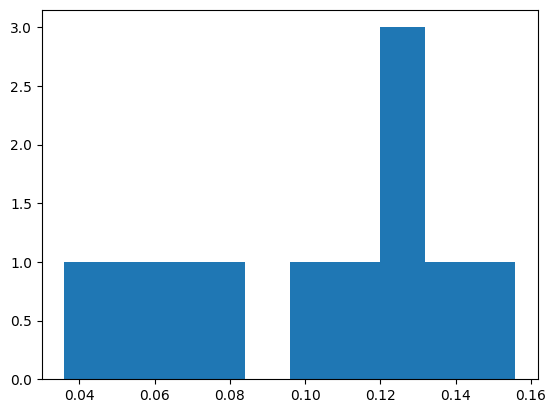

In [18]:
import matplotlib.pyplot as plt
plt.hist(r_delta_vals)

## Step 12b: Control Analysis - Delta FC with stim_amp=0

Test whether stimulus-induced FC changes are captured by the model by comparing delta FC correlation with actual stimulation vs. zero stimulation (control).

In [19]:
# Control simulation: stim_amp=0 (no actual stimulation, just stochastic effects)
print(f"\n{'='*70}")
print("CONTROL ANALYSIS: DELTA FC WITH stim_amp=0")
print(f"{'='*70}")
print(f"\nSimulating stim condition with stim_amp=0 (control)...")
print(f"This tests whether stimulus-induced FC changes are model-driven or noise-driven.")

control_results = {}

for target_idx in sorted(empirical_by_target.keys()):
    if target_idx not in simulated_by_target:
        continue

    emp_data = empirical_by_target[target_idx]
    sim_data = simulated_by_target[target_idx]

    # Get stim timings for this target
    stim_onsets_tms = representative_stim_timings.get(target_idx, np.array([]))
    if len(stim_onsets_tms) == 0:
        continue

    # Simulation parameters
    n_steps_tms = 150
    n_hcp_steps = int(np.ceil(n_steps_tms * ds_factor))

    stim_steps_tms = map_onsets_to_steps(stim_onsets_tms, tr_model=tr_stim)
    stim_steps_tms = stim_steps_tms[stim_steps_tms < n_steps_tms]
    stim_steps_hcp = np.round(stim_steps_tms * ds_factor).astype(int)
    stim_steps_hcp = stim_steps_hcp[stim_steps_hcp < n_hcp_steps]

    control_rest_fcs = []
    control_stim_fcs = []
    control_delta_fcs = []

    # Simulate for each HCP subject with stim_amp=0
    for hcp_sub_id in sorted(trained_models.keys()):
        model = trained_models[hcp_sub_id]

        # Use same random initialization as before
        init_window = create_random_init(init_method=init_method, scale=init_scale,
                                        n_rois=450, window_size=using_steps)

        # REST (same as main simulation)
        try:
            sim_rest_hires = simulate_run(
                model, init_window, n_hcp_steps,
                stim_steps=None, target_idx=None, W=None,
                burn_in=burn_in, stim_amp=stim_amp, noise_sigma=noise_sigma,
                device=device
            )
            sim_rest_downsampled = downsample_timeseries(sim_rest_hires, ds_factor)[:n_steps_tms]
            rest_fc = compute_fc_matrix(sim_rest_downsampled[:, cortical_roi_indices])
            del sim_rest_hires, sim_rest_downsampled
        except:
            continue

        # STIM with stim_amp=0 (control: no stimulation amplitude)
        try:
            sim_stim_hires = simulate_run(
                model, init_window, n_hcp_steps,
                stim_steps=stim_steps_hcp, target_idx=target_idx, W=W,
                burn_in=burn_in, stim_amp=0.0, noise_sigma=noise_sigma,  # ← stim_amp=0
                device=device
            )
            sim_stim_downsampled = downsample_timeseries(sim_stim_hires, ds_factor)[:n_steps_tms]
            stim_fc = compute_fc_matrix(sim_stim_downsampled[:, cortical_roi_indices])
            delta_fc = stim_fc - rest_fc
            del sim_stim_hires, sim_stim_downsampled
        except:
            continue

        control_rest_fcs.append(rest_fc)
        control_stim_fcs.append(stim_fc)
        control_delta_fcs.append(delta_fc)

    if len(control_delta_fcs) == 0:
        continue

    # Compute mean FC and delta FC across subjects
    mean_control_rest = np.mean(control_rest_fcs, axis=0)
    mean_control_stim = np.mean(control_stim_fcs, axis=0)
    mean_control_delta = np.mean(control_delta_fcs, axis=0)

    # Compare to empirical
    emp_delta = extract_upper_triangle(emp_data['mean_delta_fc'])

    # Correlation with actual stim (from main results)
    sim_delta_actual = extract_upper_triangle(sim_data['mean_delta_fc'])
    r_delta_actual = np.corrcoef(emp_delta, sim_delta_actual)[0, 1]

    # Correlation with stim_amp=0 (control)
    control_delta = extract_upper_triangle(mean_control_delta)
    r_delta_control = np.corrcoef(emp_delta, control_delta)[0, 1]

    # Compare
    delta_r = r_delta_actual - r_delta_control

    control_results[target_idx] = {
        'r_delta_actual': r_delta_actual,
        'r_delta_control': r_delta_control,
        'delta_r': delta_r,
        'n_sims': len(control_stim_fcs)
    }

# Display control results
print(f"\n{'='*70}")
print("CONTROL RESULTS: Delta FC Comparison")
print(f"{'='*70}")
print(f"\nTarget\t\tr_delta(stim)\tr_delta(0)\tDelta(Δr)\tSignificant?")
print("-" * 80)

for target_idx in sorted(control_results.keys()):
    res = control_results[target_idx]
    sig = "✓ YES" if res['delta_r'] > 0.01 else "✗ NO"
    print(f"{target_idx:<6}\t\t{res['r_delta_actual']:.4f}\t\t{res['r_delta_control']:.4f}\t\t{res['delta_r']:+.4f}\t\t{sig}")

print("\n" + "="*70)
print("CONTROL ANALYSIS SUMMARY")
print("="*70)

if len(control_results) > 0:
    delta_r_vals = [v['delta_r'] for v in control_results.values()]
    pos_count = sum(1 for v in delta_r_vals if v > 0.01)

    print(f"\nMean Δr (stim - stim_amp=0): {np.mean(delta_r_vals):+.4f} ± {np.std(delta_r_vals):.4f}")
    print(f"Targets with Δr > 0.01 (stimulus-driven): {pos_count}/{len(control_results)}")

    if np.mean(delta_r_vals) > 0.01:
        print(f"\n✓ EVIDENCE for stimulus-driven delta FC changes")
        print(f"  Model captures stimulus-specific dynamics beyond stochastic noise")
    else:
        print(f"\n✗ NO EVIDENCE for stimulus-driven delta FC changes")
        print(f"  Delta FC changes appear noise-driven rather than stimulus-specific")



CONTROL ANALYSIS: DELTA FC WITH stim_amp=0

Simulating stim condition with stim_amp=0 (control)...
This tests whether stimulus-induced FC changes are model-driven or noise-driven.

CONTROL RESULTS: Delta FC Comparison

Target		r_delta(stim)	r_delta(0)	Delta(Δr)	Significant?
--------------------------------------------------------------------------------
155   		0.0360		-0.1091		+0.1451		✓ YES
220   		0.1117		0.0534		+0.0582		✓ YES
231   		0.1341		0.0241		+0.1100		✓ YES
305   		0.1246		-0.0240		+0.1486		✓ YES
342   		0.1204		-0.0530		+0.1733		✓ YES
359   		0.1558		-0.0064		+0.1622		✓ YES
366   		0.0830		-0.0206		+0.1035		✓ YES
386   		0.0500		0.0229		+0.0271		✓ YES
392   		0.1060		-0.0552		+0.1612		✓ YES
401   		0.0680		0.0340		+0.0340		✓ YES
403   		0.1279		0.0014		+0.1265		✓ YES

CONTROL ANALYSIS SUMMARY

Mean Δr (stim - stim_amp=0): +0.1136 ± 0.0501
Targets with Δr > 0.01 (stimulus-driven): 11/11

✓ EVIDENCE for stimulus-driven delta FC changes
  Model captures stimulus-specific dyn

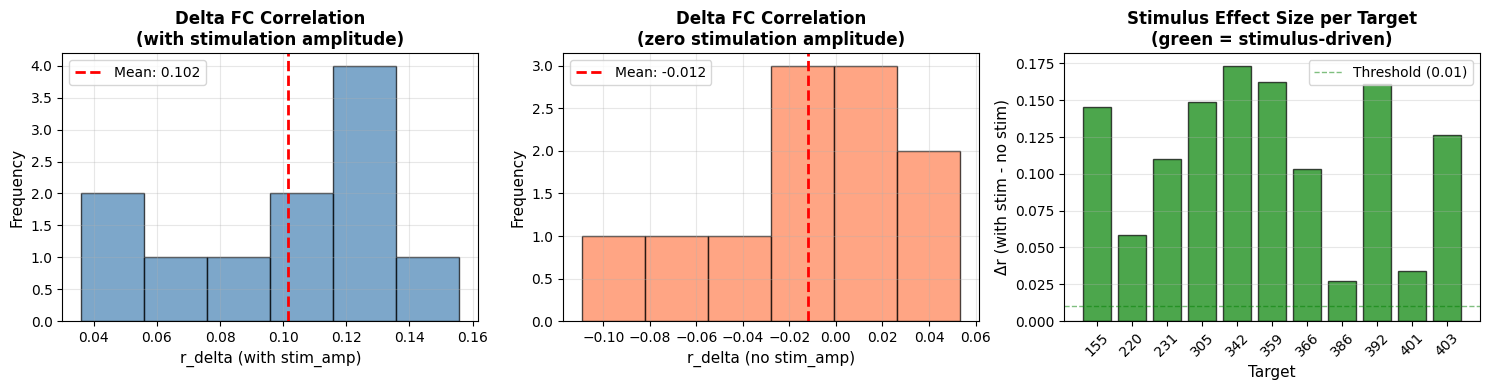


✓ Saved visualization: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/HCP_to_TMS_validation_fast/delta_fc_comparison.png


In [20]:
import matplotlib.pyplot as plt

# Prepare data for visualization
if len(control_results) > 0 and len(validation_results) > 0:
    targets = sorted(control_results.keys())
    r_delta_with_stim = [validation_results[t]['r_delta'] for t in targets if t in validation_results]
    r_delta_zero_stim = [control_results[t]['r_delta_control'] for t in targets if t in control_results]

    # Create figure with multiple subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: Histogram of r_delta with stimulation
    axes[0].hist(r_delta_with_stim, bins=6, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0].axvline(np.mean(r_delta_with_stim), color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {np.mean(r_delta_with_stim):.3f}')
    axes[0].set_xlabel('r_delta (with stim_amp)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Delta FC Correlation\n(with stimulation amplitude)', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: Histogram of r_delta with zero stimulation
    axes[1].hist(r_delta_zero_stim, bins=6, alpha=0.7, color='coral', edgecolor='black')
    axes[1].axvline(np.mean(r_delta_zero_stim), color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {np.mean(r_delta_zero_stim):.3f}')
    axes[1].set_xlabel('r_delta (no stim_amp)', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Delta FC Correlation\n(zero stimulation amplitude)', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Plot 3: Difference (Δr = stim - zero) per target
    delta_r_diff = [control_results[t]['delta_r'] for t in targets if t in control_results]
    colors = ['green' if d > 0.01 else 'gray' for d in delta_r_diff]
    axes[2].bar(range(len(targets)), delta_r_diff, color=colors, alpha=0.7, edgecolor='black')
    axes[2].axhline(0, color='black', linestyle='-', linewidth=0.8)
    axes[2].axhline(0.01, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Threshold (0.01)')
    axes[2].set_xlabel('Target', fontsize=11)
    axes[2].set_ylabel('Δr (with stim - no stim)', fontsize=11)
    axes[2].set_title('Stimulus Effect Size per Target\n(green = stimulus-driven)', fontsize=12, fontweight='bold')
    axes[2].set_xticks(range(len(targets)))
    axes[2].set_xticklabels(targets, rotation=45)
    axes[2].legend()
    axes[2].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'delta_fc_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Saved visualization: {os.path.join(out_dir, 'delta_fc_comparison.png')}")
else:
    print("⚠ Insufficient data for visualization")

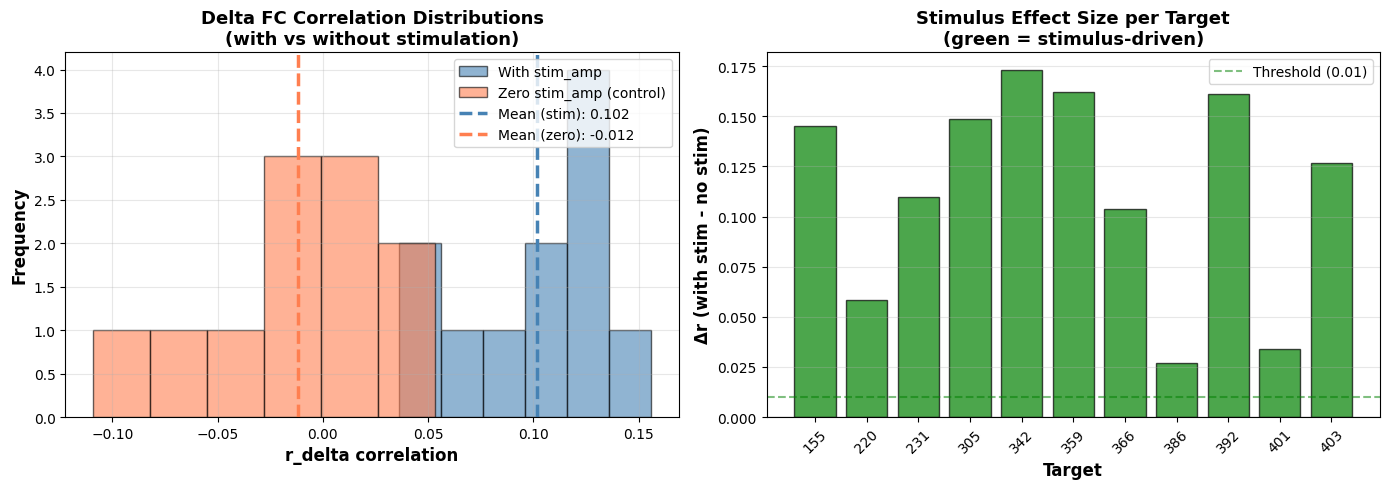


✓ Saved visualization: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/HCP_to_TMS_validation_fast/delta_fc_comparison.png


In [22]:
import matplotlib.pyplot as plt

# Prepare data for visualization
if len(control_results) > 0 and len(validation_results) > 0:
    targets = sorted(control_results.keys())
    r_delta_with_stim = [validation_results[t]['r_delta'] for t in targets if t in validation_results]
    r_delta_zero_stim = [control_results[t]['r_delta_control'] for t in targets if t in control_results]

    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Overlaid histograms - r_delta with stim vs zero stim
    axes[0].hist(r_delta_with_stim, bins=6, alpha=0.6, color='steelblue',
                 edgecolor='black', label='With stim_amp')
    axes[0].hist(r_delta_zero_stim, bins=6, alpha=0.6, color='coral',
                 edgecolor='black', label='Zero stim_amp (control)')

    # Add vertical lines for means
    axes[0].axvline(np.mean(r_delta_with_stim), color='steelblue', linestyle='--',
                    linewidth=2.5, label=f'Mean (stim): {np.mean(r_delta_with_stim):.3f}')
    axes[0].axvline(np.mean(r_delta_zero_stim), color='coral', linestyle='--',
                    linewidth=2.5, label=f'Mean (zero): {np.mean(r_delta_zero_stim):.3f}')

    axes[0].set_xlabel('r_delta correlation', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0].set_title('Delta FC Correlation Distributions\n(with vs without stimulation)',
                      fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10, loc='upper right')
    axes[0].grid(alpha=0.3)

    # Plot 2: Difference (Δr = stim - zero) per target
    delta_r_diff = [control_results[t]['delta_r'] for t in targets if t in control_results]
    colors = ['green' if d > 0.01 else 'gray' for d in delta_r_diff]
    axes[1].bar(range(len(targets)), delta_r_diff, color=colors, alpha=0.7, edgecolor='black')
    axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
    axes[1].axhline(0.01, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Threshold (0.01)')
    axes[1].set_xlabel('Target', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Δr (with stim - no stim)', fontsize=12, fontweight='bold')
    axes[1].set_title('Stimulus Effect Size per Target\n(green = stimulus-driven)',
                      fontsize=13, fontweight='bold')
    axes[1].set_xticks(range(len(targets)))
    axes[1].set_xticklabels(targets, rotation=45)
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'delta_fc_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Saved visualization: {os.path.join(out_dir, 'delta_fc_comparison.png')}")
else:
    print("⚠ Insufficient data for visualization")